In [8]:
import sys
import os
import glob
import aubio
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
print(sys.path)

['/home/gabriel/git/rizhom/env/lib/python36.zip', '/home/gabriel/git/rizhom/env/lib/python3.6', '/home/gabriel/git/rizhom/env/lib/python3.6/lib-dynload', '/usr/lib/python3.6', '', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages/IPython/extensions', '/home/gabriel/.ipython']


In [59]:
data_path = "../data"
paths = sorted(glob.glob("../data/rec_1/*.jpg"))
data = None
for i, file in enumerate(paths):
    im = np.array(Image.open(file)).astype(np.int16)[:,:,1]
    if data is None:
        data = np.zeros([len(paths) - 1, im.shape[0], im.shape[1]])
        im0 = im
        continue
    data[i-1,:,:] = np.clip(im - im0, 0, 255).astype(np.int8)
    if i > 5: break

In [60]:
(im[:,:,1] - im0).dtype

dtype('int16')

(array([1.546041e+06, 9.580700e+04, 7.515300e+04, 3.952400e+04,
        6.576600e+04, 1.082090e+05, 1.059390e+05, 2.974100e+04,
        1.025000e+03, 6.395000e+03]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <a list of 10 Patch objects>)

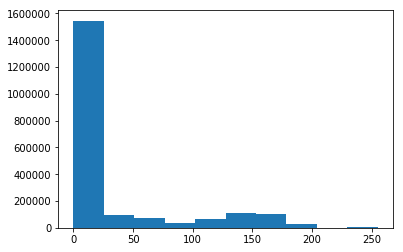

In [63]:
plt.hist(im0.reshape(-1))

(array([4514898.,  372656.,  222001.,  155714.,  262909.,  309583.,
         260805.,   78888.,   17625.,   25721.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <a list of 10 Patch objects>)

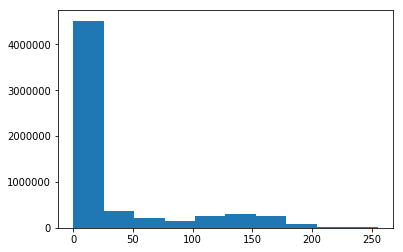

In [62]:
plt.hist(im.reshape(-1))

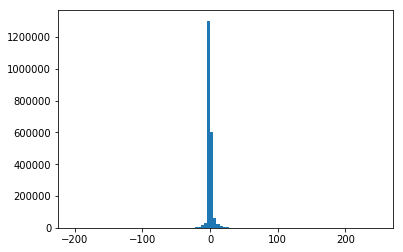

In [61]:
plt.hist((im[:,:,1] - im0).reshape(-1), bins=100);

In [35]:
import numpy as np
from numpy import pi, r_
import matplotlib.pyplot as plt
from scipy import optimize

def gaussian(height, center_x, center_y, width_x, width_y):
    """Returns a gaussian function with the given parameters"""
    width_x = float(width_x)
    width_y = float(width_y)
    return lambda x,y: height*np.exp(
                -(((center_x-x)/width_x)**2+((center_y-y)/width_y)**2)/2)

def moments(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution by calculating its
    moments """
    total = data.sum()
    X, Y = np.indices(data.shape)
    x = (X*data).sum()/total
    y = (Y*data).sum()/total
    col = data[:, int(y)]
    width_x = np.sqrt(np.abs((np.arange(col.size)-y)**2*col).sum()/col.sum())
    row = data[int(x), :]
    width_y = np.sqrt(np.abs((np.arange(row.size)-x)**2*row).sum()/row.sum())
    height = data.max()
    return height, x, y, width_x, width_y

def fitgaussian(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution found by a fit"""
    params = moments(data)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(data.shape)) -
                                 data)
    p, success = optimize.leastsq(errorfunction, params)
    return p

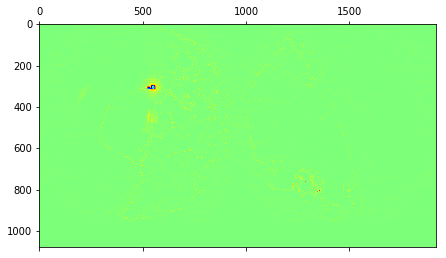

In [32]:
ref_img.shape
plt.matshow(data[0], cmap='jet')

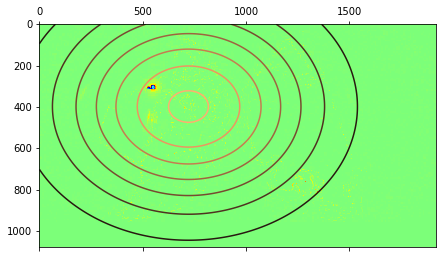

In [39]:
plt.matshow(data[0], cmap='jet')

params = fitgaussian(data[0])
fit = gaussian(*params)

plt.contour(fit(*np.indices(data.shape[1:])), cmap=plt.cm.copper)
ax = plt.gca()
(height, x, y, width_x, width_y) = params


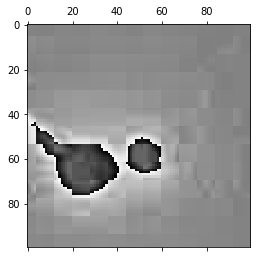

In [52]:
plt.matshow(data[2, 250:350, 500:600], cmap='gray')
